# EDA — DataCollectionAgent
## Задание 1 | Sentiment Analysis

Анализ датасета собранного `DataCollectionAgent`:
- Источник 1: IMDB (HuggingFace)
- Источник 2: books.toscrape.com (scraping)

**Схема данных:** `text`, `label`, `source`, `collected_at`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

sns.set_theme(style="whitegrid")

df = pd.read_parquet("../data/raw/collected.parquet")
print(f"Датасет: {df.shape[0]} записей, {df.shape[1]} колонок")
print(f"\nКолонки: {list(df.columns)}")
print(f"\nИсточники:")
print(df["source"].value_counts().to_string())
df.head(3)

Датасет: 2017 записей, 4 колонок

Колонки: ['text', 'label', 'source', 'collected_at']

Источники:
source
hf:imdb                             2000
scrape:http://books.toscrape.com      17


,text,label,source,collected_at
0,"Dumb is as dumb does, in this thoroughly unint...",negative,hf:imdb,2026-03-26T03:16:27.634498
1,I dug out from my garage some old musicals and...,positive,hf:imdb,2026-03-26T03:16:27.634498
2,After watching this movie I was honestly disap...,negative,hf:imdb,2026-03-26T03:16:27.634498


## 1. Распределение классов

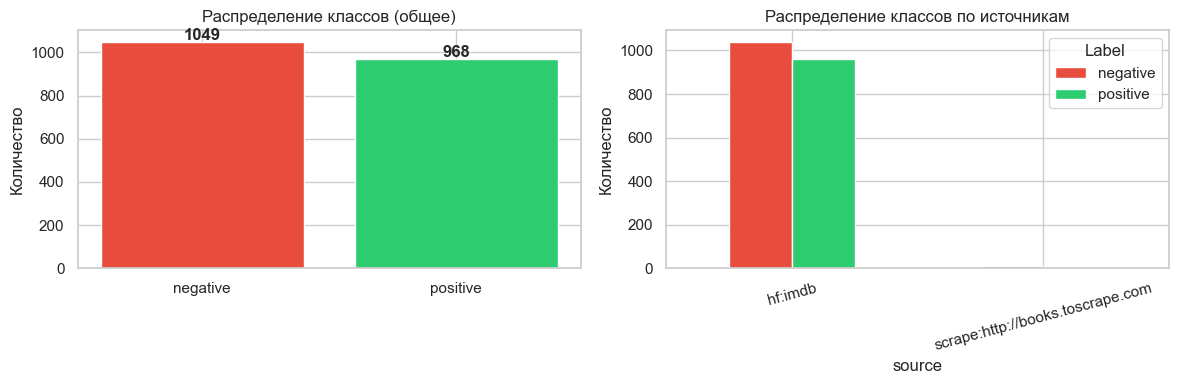


Дисбаланс классов: 1.08x


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Общее распределение
label_counts = df["label"].value_counts()
axes[0].bar(label_counts.index, label_counts.values, color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Распределение классов (общее)")
axes[0].set_ylabel("Количество")
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

# По источникам
pivot = df.groupby(["source", "label"]).size().unstack(fill_value=0)
pivot.plot(kind="bar", ax=axes[1], color=["#e74c3c", "#2ecc71"], rot=15)
axes[1].set_title("Распределение классов по источникам")
axes[1].set_ylabel("Количество")
axes[1].legend(title="Label")

plt.tight_layout()
plt.savefig("../reports/class_distribution.png", dpi=150)
plt.show()
print(f"\nДисбаланс классов: {label_counts.max()/label_counts.min():.2f}x")

## 2. Длины текстов

Статистика длин текстов:
       text_length  word_count
count       2017.0      2017.0
mean        1300.1       228.8
std          985.5       169.8
min            4.0         1.0
25%          683.0       125.0
50%          953.0       169.0
75%         1613.0       282.0
max         6122.0      1021.0


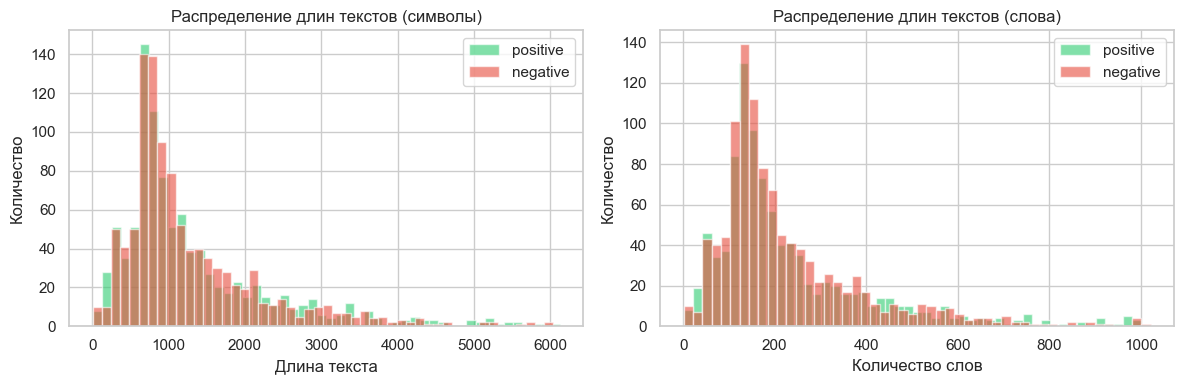

In [3]:
df["text_length"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

print("Статистика длин текстов:")
print(df[["text_length", "word_count"]].describe().round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, color in [("positive", "#2ecc71"), ("negative", "#e74c3c")]:
    subset = df[df["label"] == label]["text_length"]
    axes[0].hist(subset, bins=50, alpha=0.6, label=label, color=color)
axes[0].set_title("Распределение длин текстов (символы)")
axes[0].set_xlabel("Длина текста")
axes[0].set_ylabel("Количество")
axes[0].legend()

for label, color in [("positive", "#2ecc71"), ("negative", "#e74c3c")]:
    subset = df[df["label"] == label]["word_count"]
    axes[1].hist(subset, bins=50, alpha=0.6, label=label, color=color)
axes[1].set_title("Распределение длин текстов (слова)")
axes[1].set_xlabel("Количество слов")
axes[1].set_ylabel("Количество")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/text_lengths.png", dpi=150)
plt.show()

## 3. Топ-20 слов

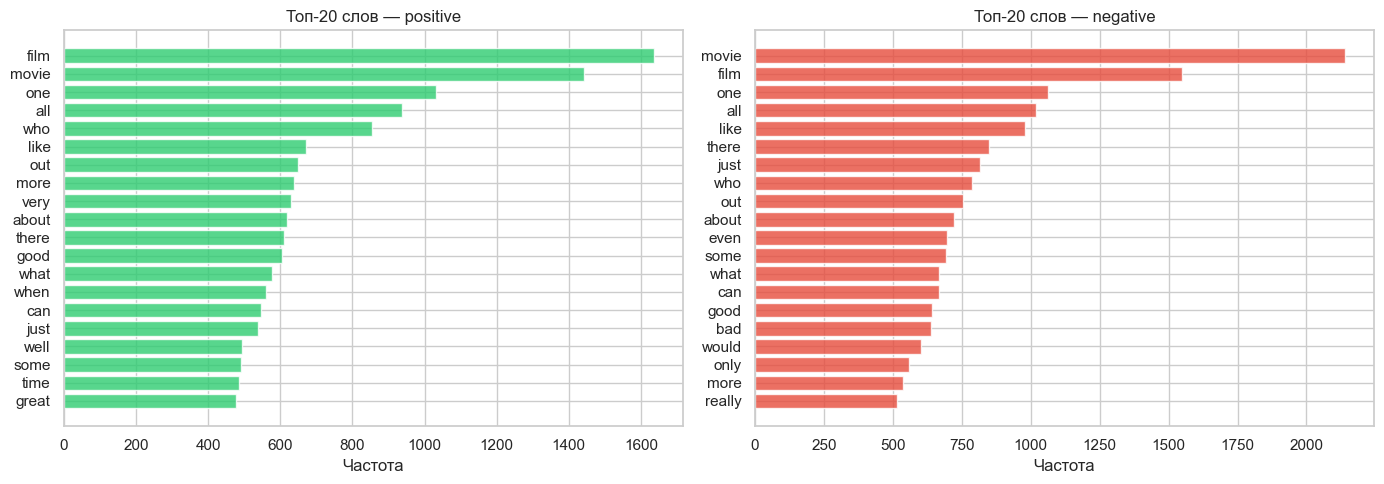

In [4]:
STOPWORDS = {"the","a","an","and","or","but","in","on","at","to","for","of","with",
             "is","was","it","this","that","as","be","are","were","i","he","she",
             "they","we","you","have","has","had","not","by","from","his","her","my"}

def get_top_words(texts, n=20):
    words = []
    for text in texts:
        tokens = re.findall(r'\b[a-z]{3,}\b', str(text).lower())
        words.extend([w for w in tokens if w not in STOPWORDS])
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, label, color in [(axes[0], "positive", "#2ecc71"), (axes[1], "negative", "#e74c3c")]:
    top = get_top_words(df[df["label"] == label]["text"])
    words, counts = zip(*top)
    ax.barh(list(reversed(words)), list(reversed(counts)), color=color, alpha=0.8)
    ax.set_title(f"Топ-20 слов — {label}")
    ax.set_xlabel("Частота")

plt.tight_layout()
plt.savefig("../reports/top20_words.png", dpi=150)
plt.show()